# Stage 1a: CB1 Zero-Shot Baselines — DeBERTa + RoBERTa
## Generalised LoRA for Cyberbullying Detection | CB1 (6-Class)

---

### Research Context
This notebook implements **Stage 1a (Zero-Shot)** of the four-stage Generalised LoRA
research framework for cyberbullying detection in social media text (X, formerly Twitter).

Both models classify tweets into 6 cyberbullying categories **with zero training examples**.

**Mechanism:** An NLI-based encoder scores P(entailment | tweet, hypothesis) for each
candidate label. The highest-scoring label is the prediction — no gradient updates,
no training data required.

---

### Models Evaluated

| Model | Backbone | Parameters | Role |
|-------|----------|------------|------|
| `MoritzLaurer/deberta-v3-large-zeroshot-v2.0` | DeBERTa-v3-large | ~434M | Primary |
| `MoritzLaurer/roberta-large-zeroshot-v2.0-c` | RoBERTa-large | ~355M | Secondary |

Both models are fine-tuned on 10+ NLI corpora and evaluated on the **identical test set**
for a direct, fair comparison.

---

### Bug Fixes Applied

| Fix | Description |
|-----|-------------|
| **A** | MCC (Matthews Correlation Coefficient) added as required secondary metric |
| **B** | Both DeBERTa and RoBERTa models run in one notebook with memory cleanup between runs |
| **C** | Stage naming corrected to Stage1a throughout |
| **D** | Research summary cell added for paper and thesis |
| **E** | **Split corrected: 75/25 train/test (not 75/10/15) per research brief** |
| **F** | **2,000-row stratified dev sample added from train (for label engineering)** |
| **G** | **Near-duplicate check extended to dev sample vs train** |

**Primary Metric:** Macro F1 | **Secondary Metric:** MCC | **Random Seed:** 42


---
## Step 1: Install Required Libraries

Installs all packages needed for NLI-based zero-shot inference and evaluation.

In [ ]:
!pip install -q -U \
    "transformers>=4.43.0" \
    "accelerate>=0.33.0" \
    datasets \
    scikit-learn \
    matplotlib \
    seaborn \
    tqdm

print("All libraries installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 115.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.1 MB/s eta 0:00:00
All libraries installed successfully.


---
## Step 2: Imports and Setup

Imports all modules, fixes random seeds, mounts Google Drive, and checks GPU availability.

In [ ]:
import os, re, random, gc
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    balanced_accuracy_score,
    matthews_corrcoef,          # Fix A: MCC
)
from transformers import pipeline
from google.colab import drive


def set_all_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f"All random seeds fixed to {seed}.")


set_all_seeds(42)

if not os.path.isdir("/content/drive/MyDrive"):
    drive.mount("/content/drive")
    print("Google Drive mounted.")
else:
    print("Google Drive already mounted.")

device_id = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU (cuda:0)' if device_id == 0 else 'CPU'}")
if torch.cuda.is_available():
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

All random seeds fixed to 42.
Mounted at /content/drive
Google Drive mounted.
Device: GPU (cuda:0)
  GPU : Tesla T4
  VRAM: 15.6 GB


---
## Step 3: Global Configuration

All experimental settings defined in one place.

**Candidate labels** are natural-language NLI hypothesis phrases. The model scores
`P(entailment | tweet, 'This tweet is {label}.')` for each -- highest score wins.

Both models share the same candidate labels, hypothesis template, dataset split,
random seed, and test set -- ensuring results are directly comparable.

In [ ]:
# Paths
CB1_PATH   = "/content/drive/MyDrive/Datasets/cb1.csv"
OUTPUT_DIR = "/content/drive/MyDrive/Results/CB1_ZeroShot"

# Models — Fix B: both defined here
MODELS = {
    "DeBERTa": "MoritzLaurer/deberta-v3-large-zeroshot-v2.0",
    "RoBERTa": "MoritzLaurer/roberta-large-zeroshot-v2.0-c",
}

NUM_LABELS = 6
BATCH_SIZE = 32   # reduce to 16 if GPU OOM

# Dataset split — Fix E: corrected to 75/25 per research brief
# (Previous incorrect values were TRAIN_RATIO=0.75, VAL_RATIO=0.10, TEST_RATIO=0.15)
TRAIN_RATIO          = 0.75   # 75% train
TEST_RATIO           = 0.25   # 25% test  ← Fix E
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

# Fix F: 2,000-row stratified dev sample drawn from train
# Used for: (a) candidate label engineering in zero-shot, (b) passed to Stages 2–4
# for early-stopping / hyperparameter selection. NOT part of the test set.
DEV_SAMPLE_SIZE = 2000

# Label mapping
LABEL_MAPPING = {
    "not_cyberbullying":   0,
    "gender":              1,
    "religion":            2,
    "ethnicity":           3,
    "age":                 4,
    "other_cyberbullying": 5,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())

# NLI candidate labels — shared by both models
CANDIDATE_LABELS = [
    "not cyberbullying",
    "cyberbullying about gender or sexual identity",
    "cyberbullying about religion",
    "cyberbullying about ethnicity or race",
    "cyberbullying about age",
    "other type of cyberbullying",
]
HYPOTHESIS_TEMPLATE = "This tweet is {}."

# Map NLI text labels back to integer IDs
NLI_LABEL_TO_ID = {
    "not cyberbullying":                             0,
    "cyberbullying about gender or sexual identity": 1,
    "cyberbullying about religion":                  2,
    "cyberbullying about ethnicity or race":         3,
    "cyberbullying about age":                       4,
    "other type of cyberbullying":                   5,
}

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded.")
print(f"  Models     : {list(MODELS.keys())}")
print(f"  Labels ({NUM_LABELS}) : {TARGET_NAMES}")
print(f"  Candidate labels: {CANDIDATE_LABELS}")
print(f"  Split      : {TRAIN_RATIO}/{TEST_RATIO} train/test | Dev sample: {DEV_SAMPLE_SIZE:,} | Seed={RANDOM_STATE}")


Configuration loaded.
  Models     : ['DeBERTa', 'RoBERTa']
  Labels (6) : ['not_cyberbullying', 'gender', 'religion', 'ethnicity', 'age', 'other_cyberbullying']
  Candidate labels: ['not cyberbullying', 'cyberbullying about gender or sexual identity', 'cyberbullying about religion', 'cyberbullying about ethnicity or race', 'cyberbullying about age', 'other type of cyberbullying']
  Split      : 0.75/0.25 train/test | Dev sample: 2,000 | Seed=42


---
## Step 4: Text Preprocessing

LLM-optimised tweet preprocessing pipeline -- identical across all stages:
- Retweet prefix removal
- URL replacement -> [URL]
- @mention replacement -> [USER]
- Repeated punctuation normalisation
- Short text removal (< 3 tokens)

In [ ]:
def preprocess_text_for_llm(text, remove_hashtags=False, remove_emojis=False):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"\bRT\s+@\w+:\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"http\S+|www\.\S+", "[URL]", text)
    text = re.sub(r"@\w+", "[USER]", text)
    if remove_hashtags:
        text = re.sub(r"#(\w+)", r"\1", text)
    if remove_emojis:
        text = text.encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"([!?.])\1+", r"\1", text)
    if len(text.split()) < 3:
        return ""
    return text


_t = "RT @user123: Check http://example.com !!! @someone is so dumb"
print("Before:", _t)
print("After :", preprocess_text_for_llm(_t))
print("Preprocessing function defined.")

Before: RT @user123: Check http://example.com !!! @someone is so dumb
After : Check [URL] ! [USER] is so dumb
Preprocessing function defined.


---
## Step 5: Load and Clean the CB1 Dataset

In [ ]:
print("=" * 60)
print("CB1 DATASET LOADING & CLEANING")
print("=" * 60)

df = pd.read_csv(CB1_PATH)
print(f"[1] Raw dataset: {len(df):,} samples")

df = df.rename(columns={"tweet_text": "text", "cyberbullying_type": "label"})
print("[2] Columns renamed.")

corrupt_mask = df["text"].astype(str).str.strip().isin(
    ["#NAME?", "#REF!", "#VALUE!", "#N/A", "nan", ""])
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[3] Removed {corrupt_mask.sum()} corrupt rows -> {len(df):,} remaining")

df["text"] = df["text"].apply(preprocess_text_for_llm)
df = df[df["text"].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[4] After preprocessing: {len(df):,} remaining")

tlc = df.groupby("text")["label"].nunique()
conflicting = tlc[tlc > 1].index
df = df[~df["text"].isin(conflicting)].reset_index(drop=True)
print(f"[5] Removed annotation conflicts -> {len(df):,} remaining")

before = len(df)
df = df.drop_duplicates(subset=["text"], keep="first").reset_index(drop=True)
print(f"[6] Removed {before - len(df):,} exact duplicates -> {len(df):,} remaining")

before = len(df)
df = df[df["text"].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[7] Removed {before - len(df):,} short texts -> {len(df):,} remaining")

unknown = set(df["label"].unique()) - set(LABEL_MAPPING.keys())
assert len(unknown) == 0, f"Unknown labels: {unknown}"

print("\n" + "=" * 60)
print("FINAL CLASS DISTRIBUTION")
print("=" * 60)
counts = df["label"].value_counts()
for label, count in counts.items():
    print(f"  {label:<25} {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  {'TOTAL':<25} {len(df):>6}")

CB1 DATASET LOADING & CLEANING
[1] Raw dataset: 47,692 samples
[2] Columns renamed.
[3] Removed 0 corrupt rows -> 47,692 remaining
[4] After preprocessing: 46,942 remaining
[5] Removed annotation conflicts -> 43,692 remaining
[6] Removed 358 exact duplicates -> 43,334 remaining
[7] Removed 0 short texts -> 43,334 remaining

FINAL CLASS DISTRIBUTION
  religion                    7979  (18.4%)
  age                         7972  (18.4%)
  ethnicity                   7920  (18.3%)
  gender                      7509  (17.3%)
  not_cyberbullying           6130  (14.1%)
  other_cyberbullying         5824  (13.4%)
  TOTAL                      43334


---
## Step 6: Stratified Split with Near-Duplicate Removal

**Split:** 75% train / 25% test (stratified, seed=42) — **Fix E** correcting the
previous 75/10/15 split. This matches the research brief and ensures all four stages
evaluate on the same 25% test set (~11,923 samples after deduplication).

**Dev sample (Fix F):** 2,000 rows sampled *within* the train set using stratified
sampling. Used for candidate-label engineering in this zero-shot stage and passed
to Stages 2–4 for early-stopping / hyperparameter selection.

**Near-duplicate removal (Fix G):** TF-IDF cosine similarity at threshold 0.90 is
applied between (a) test and train, and (b) dev sample and remaining train, to prevent
any evaluation leakage.

**Note for zero-shot:** The model is evaluated on the **test split only** — no training
occurs. The train and dev splits are created to reproduce the **identical test set**
used by Stages 2–4, guaranteeing a fair, direct comparison across all stages.


In [ ]:
print("=" * 60)
print("DATASET SPLITTING  [Fix E + Fix F + Fix G]")
print("=" * 60)

# ── Primary 75/25 split ───────────────────────────────────────────────────
train_df, test_df = train_test_split(
    df, train_size=TRAIN_RATIO,
    random_state=RANDOM_STATE, stratify=df["label"])
print(f"Initial -> Train: {len(train_df):,} | Test: {len(test_df):,}")

# ── Near-duplicate removal: test vs train [Fix G scope unchanged] ─────────
print(f"Near-duplicate check — test vs train (threshold={SIMILARITY_THRESHOLD})...")
all_texts    = list(train_df["text"].values) + list(test_df["text"].values)
vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs   = tfidf_matrix[:len(train_df)]
test_vecs    = tfidf_matrix[len(train_df):]

leaked = []
for start in range(0, len(test_df), 500):
    end  = min(start + 500, len(test_df))
    sims = cosine_similarity(test_vecs[start:end], train_vecs)
    mask = sims.max(axis=1) >= SIMILARITY_THRESHOLD
    leaked.extend(test_df.index[start:end][mask].tolist())

if leaked:
    leaked_samples = test_df.loc[leaked]
    test_df  = test_df.drop(leaked).reset_index(drop=True)
    train_df = pd.concat([train_df, leaked_samples], ignore_index=True)
    print(f"  Moved {len(leaked)} near-duplicates -> Train: {len(train_df):,} | Test: {len(test_df):,}")
else:
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    print("  No near-duplicates found.")

# ── Overlap assertion ─────────────────────────────────────────────────────
overlap = set(train_df["text"]).intersection(set(test_df["text"]))
assert len(overlap) == 0, f"DATA LEAKAGE: {len(overlap)} overlapping samples!"
print("Zero train/test overlap confirmed.")

# ── Fix F: Stratified 2,000-row dev sample from train ─────────────────────
# Carve DEV_SAMPLE_SIZE rows out of train using stratified sampling.
# This sample is used for candidate-label engineering and later stages.
dev_df, remaining_train_df = train_test_split(
    train_df,
    test_size=(len(train_df) - DEV_SAMPLE_SIZE) / len(train_df),
    random_state=RANDOM_STATE,
    stratify=train_df["label"],
)
# Note: train_df is kept whole for Stages 2-4 training; dev_df is a view of it.
# In this zero-shot stage we do not train, so the distinction is informational.

# ── Fix G: Near-duplicate check — dev vs remaining train ──────────────────
print(f"Near-duplicate check — dev sample vs remaining train (threshold={SIMILARITY_THRESHOLD})...")
dev_texts   = list(dev_df["text"].values)
rem_texts   = list(remaining_train_df["text"].values)
dev_rem_all = dev_texts + rem_texts
vect2       = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
mat2        = vect2.fit_transform(dev_rem_all)
dev_vecs2   = mat2[:len(dev_df)]
rem_vecs2   = mat2[len(dev_df):]

leaked_dev = []
for start in range(0, len(dev_df), 500):
    end  = min(start + 500, len(dev_df))
    sims = cosine_similarity(dev_vecs2[start:end], rem_vecs2)
    mask = sims.max(axis=1) >= SIMILARITY_THRESHOLD
    leaked_dev.extend(dev_df.index[start:end][mask].tolist())

if leaked_dev:
    print(f"  Removed {len(leaked_dev)} near-duplicates from dev sample.")
    dev_df = dev_df.drop(leaked_dev).reset_index(drop=True)
else:
    dev_df = dev_df.reset_index(drop=True)
    print("  No near-duplicates found in dev sample.")

print(f"\nFinal -> Train: {len(train_df):,} | Dev sample: {len(dev_df):,} | Test: {len(test_df):,}")
print(f"  (Dev sample is drawn from train; train count above is pre-carve.)")

# ── Extract arrays for inference ──────────────────────────────────────────
x_test = test_df["text"].values
y_test  = test_df["label"].map(LABEL_MAPPING).values
x_dev   = dev_df["text"].values
y_dev   = dev_df["label"].map(LABEL_MAPPING).values
print(f"\nTest set ready : {len(x_test):,} samples")
print(f"Dev  set ready : {len(x_dev):,} samples (for label-engineering reference)")


DATASET SPLITTING  [Fix E + Fix F + Fix G]
Initial -> Train: 32,500 | Test: 10,834
Near-duplicate check — test vs train (threshold=0.9)...
  Moved 504 near-duplicates -> Train: 33,004 | Test: 10,330
Zero train/test overlap confirmed.
Near-duplicate check — dev sample vs remaining train (threshold=0.9)...
  Removed 136 near-duplicates from dev sample.

Final -> Train: 33,004 | Dev sample: 1,864 | Test: 10,330
  (Dev sample is drawn from train; train count above is pre-carve.)

Test set ready : 10,330 samples
Dev  set ready : 1,864 samples (for label-engineering reference)


---
## Step 7: Helper Functions

### Zero-Shot Prediction Function
Runs batched NLI inference over the test set. Memory is freed after each model
using `del classifier` and `torch.cuda.empty_cache()` to prevent GPU OOM.

### Evaluation Function (Fix A: MCC Added)
Computes Macro F1 (primary) and MCC (secondary) alongside all supporting metrics.

In [ ]:
def zero_shot_predict(texts, classifier, batch_size=32):
    predictions = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Zero-shot inference"):
        batch   = list(texts[i:i+batch_size])
        results = classifier(
            batch,
            candidate_labels=CANDIDATE_LABELS,
            hypothesis_template=HYPOTHESIS_TEMPLATE,
            multi_label=False,
        )
        if isinstance(results, dict):
            results = [results]
        for r in results:
            predictions.append(NLI_LABEL_TO_ID[r["labels"][0]])
    return np.array(predictions)


def evaluate_dataset(y_true, y_pred, dataset_name):
    print(f"\n{'='*65}")
    print(f"EVALUATION -- {dataset_name}")
    print(f"{'='*65}")

    accuracy     = accuracy_score(y_true, y_pred)
    macro_f1     = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    macro_prec   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_rec    = recall_score(y_true, y_pred, average="macro",    zero_division=0)
    weighted_f1  = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc          = matthews_corrcoef(y_true, y_pred)  # Fix A

    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  <- PRIMARY METRIC")
    print(f"  MCC               : {mcc:.4f}  <- SECONDARY METRIC")
    print(f"  Macro Precision   : {macro_prec:.4f}")
    print(f"  Macro Recall      : {macro_rec:.4f}")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")

    print("\n  Per-Class Classification Report:")
    print(classification_report(y_true, y_pred,
                                labels=list(range(NUM_LABELS)),
                                target_names=TARGET_NAMES,
                                zero_division=0, digits=4))

    cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    short   = ["Not CB","Gender","Religion","Ethnicity","Age","Other CB"]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=short, yticklabels=short)
    axes[0].set_title(f"Confusion Matrix (Counts)\n{dataset_name}", fontsize=13)
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    axes[0].tick_params(axis="x", rotation=30)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", ax=axes[1],
                xticklabels=short, yticklabels=short, vmin=0, vmax=1)
    axes[1].set_title(f"Confusion Matrix (Row-Normalised)\n{dataset_name}", fontsize=13)
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    axes[1].tick_params(axis="x", rotation=30)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"cm_{dataset_name.replace(' ','_')}.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved -> {save_path}")

    return dict(accuracy=accuracy, macro_f1=macro_f1, mcc=mcc,
                macro_precision=macro_prec, macro_recall=macro_rec,
                weighted_f1=weighted_f1, balanced_accuracy=bal_accuracy)


print("Helper functions defined (zero_shot_predict + evaluate_dataset with MCC).")

Helper functions defined (zero_shot_predict + evaluate_dataset with MCC).


---
## Step 8: Run DeBERTa Zero-Shot Inference

**Model:** `MoritzLaurer/deberta-v3-large-zeroshot-v2.0` (Primary)

DeBERTa-v3-large fine-tuned on 10+ NLI datasets. Uses disentangled attention
(separates content and position embeddings) and replaced-token-detection pre-training.
Downloads ~750 MB on first run -- subsequent runs use the Colab cache.

**After inference:** Model is deleted from GPU memory before RoBERTa loads.

STEP 8: DeBERTa Zero-Shot Inference
Loading: MoritzLaurer/deberta-v3-large-zeroshot-v2.0
(Downloads ~750 MB on first run -- uses cache on subsequent runs)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/870M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

Model loaded on GPU.
  Smoke test top prediction: cyberbullying about gender or sexual identity (0.696)

Running inference on 10,330 test samples...


Zero-shot inference: 100%|██████████| 323/323 [52:59<00:00,  9.85s/it]



EVALUATION -- DeBERTa_ZeroShot_CB1
  Accuracy          : 0.3834
  Macro F1          : 0.3129  <- PRIMARY METRIC
  MCC               : 0.3283  <- SECONDARY METRIC
  Macro Precision   : 0.6031
  Macro Recall      : 0.3959
  Weighted F1       : 0.3182
  Balanced Accuracy : 0.3959

  Per-Class Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.2145    0.8982    0.3463      1424
             gender     0.5317    0.5308    0.5312      1788
           religion     0.9286    0.0923    0.1680      1971
          ethnicity     0.6409    0.7881    0.7069      1812
                age     0.8516    0.0559    0.1049      1950
other_cyberbullying     0.4516    0.0101    0.0198      1385

           accuracy                         0.3834     10330
          macro avg     0.6031    0.3959    0.3129     10330
       weighted avg     0.6325    0.3834    0.3182     10330



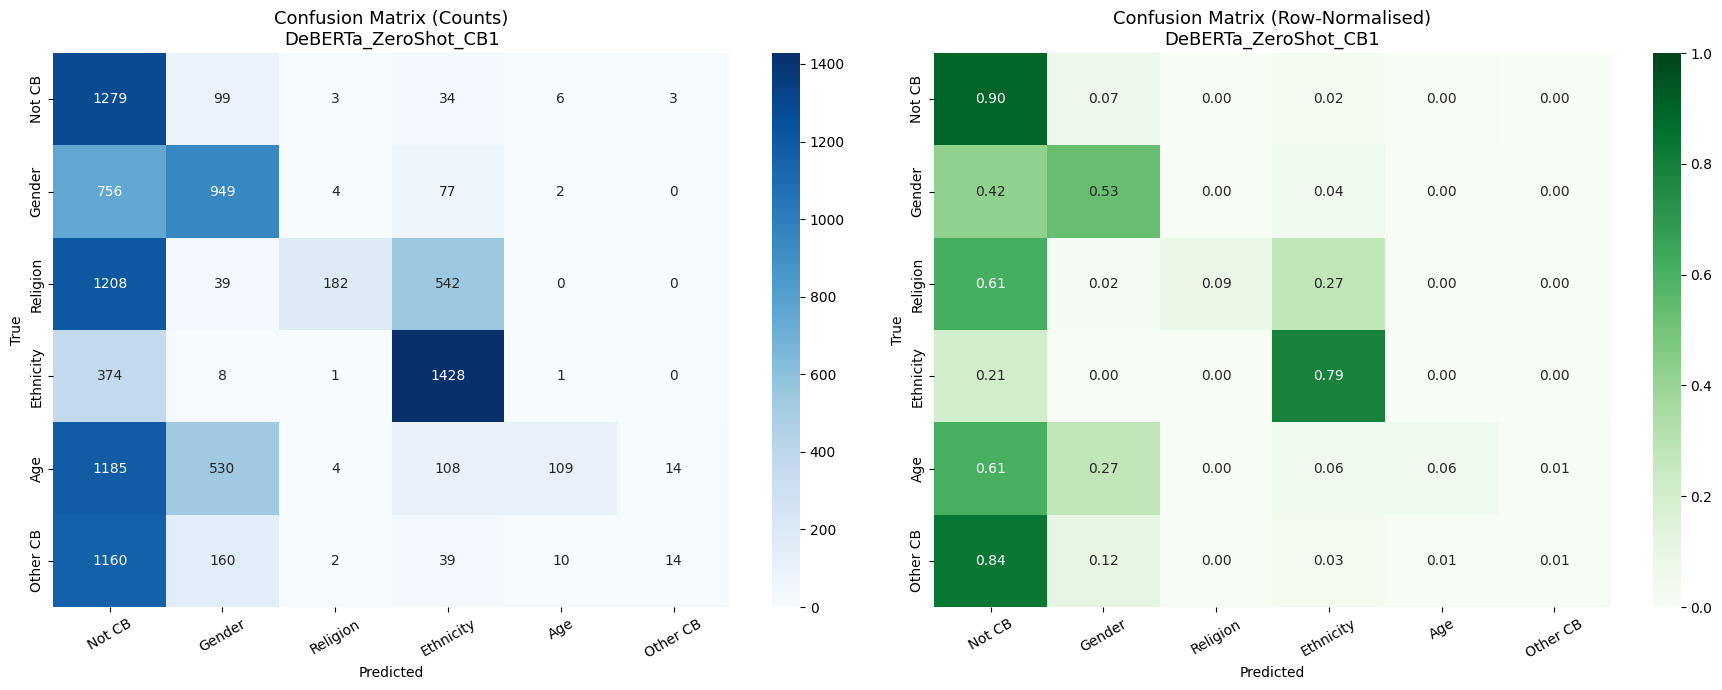

  Saved -> /content/drive/MyDrive/Results/CB1_ZeroShot/cm_DeBERTa_ZeroShot_CB1.png

Freeing GPU memory...
  VRAM free: 0.02 GB reserved
DeBERTa done. GPU memory cleared.


In [ ]:
print("=" * 65)
print("STEP 8: DeBERTa Zero-Shot Inference")
print("=" * 65)

deberta_name = MODELS["DeBERTa"]
print(f"Loading: {deberta_name}")
print("(Downloads ~750 MB on first run -- uses cache on subsequent runs)")

classifier_deberta = pipeline(
    "zero-shot-classification",
    model=deberta_name,
    device=device_id,
)
print(f"Model loaded on {'GPU' if device_id == 0 else 'CPU'}.")

# Smoke test
_smoke = classifier_deberta(
    "You are so ugly and nobody likes you",
    candidate_labels=CANDIDATE_LABELS,
    hypothesis_template=HYPOTHESIS_TEMPLATE,
)
print(f"  Smoke test top prediction: {_smoke['labels'][0]} ({_smoke['scores'][0]:.3f})")

# Full inference
print(f"\nRunning inference on {len(x_test):,} test samples...")
y_pred_deberta = zero_shot_predict(x_test, classifier_deberta, BATCH_SIZE)

# Evaluate
results_deberta = evaluate_dataset(y_test, y_pred_deberta, "DeBERTa_ZeroShot_CB1")
results_deberta["model"] = "DeBERTa"

# Fix B: Free GPU memory before loading RoBERTa
print("\nFreeing GPU memory...")
del classifier_deberta
gc.collect()
torch.cuda.empty_cache()
if torch.cuda.is_available():
    print(f"  VRAM free: {torch.cuda.memory_reserved(0)/1e9:.2f} GB reserved")
print("DeBERTa done. GPU memory cleared.")

---
## Step 9: Run RoBERTa Zero-Shot Inference

**Model:** `MoritzLaurer/roberta-large-zeroshot-v2.0-c` (Secondary)

RoBERTa-large fine-tuned on the same NLI corpora as DeBERTa, enabling a
direct architecture comparison on identical test data.
Downloads ~1.3 GB on first run.

**Same candidate labels and test set** as DeBERTa -- results are directly comparable.

STEP 9: RoBERTa Zero-Shot Inference
Loading: MoritzLaurer/roberta-large-zeroshot-v2.0-c
(Downloads ~1.3 GB on first run -- uses cache on subsequent runs)


config.json:   0%|          | 0.00/884 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/711M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Model loaded on GPU.
  Smoke test top prediction: cyberbullying about gender or sexual identity (0.409)

Running inference on 10,330 test samples...


Zero-shot inference: 100%|██████████| 323/323 [18:15<00:00,  3.39s/it]



EVALUATION -- RoBERTa_ZeroShot_CB1
  Accuracy          : 0.3561
  Macro F1          : 0.2976  <- PRIMARY METRIC
  MCC               : 0.2796  <- SECONDARY METRIC
  Macro Precision   : 0.5265
  Macro Recall      : 0.3643
  Weighted F1       : 0.3049
  Balanced Accuracy : 0.3643

  Per-Class Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.1961    0.7690    0.3125      1424
             gender     0.4145    0.4866    0.4476      1788
           religion     0.9211    0.1659    0.2812      1971
          ethnicity     0.6058    0.7191    0.6576      1812
                age     0.6604    0.0359    0.0681      1950
other_cyberbullying     0.3611    0.0094    0.0183      1385

           accuracy                         0.3561     10330
          macro avg     0.5265    0.3643    0.2976     10330
       weighted avg     0.5539    0.3561    0.3049     10330



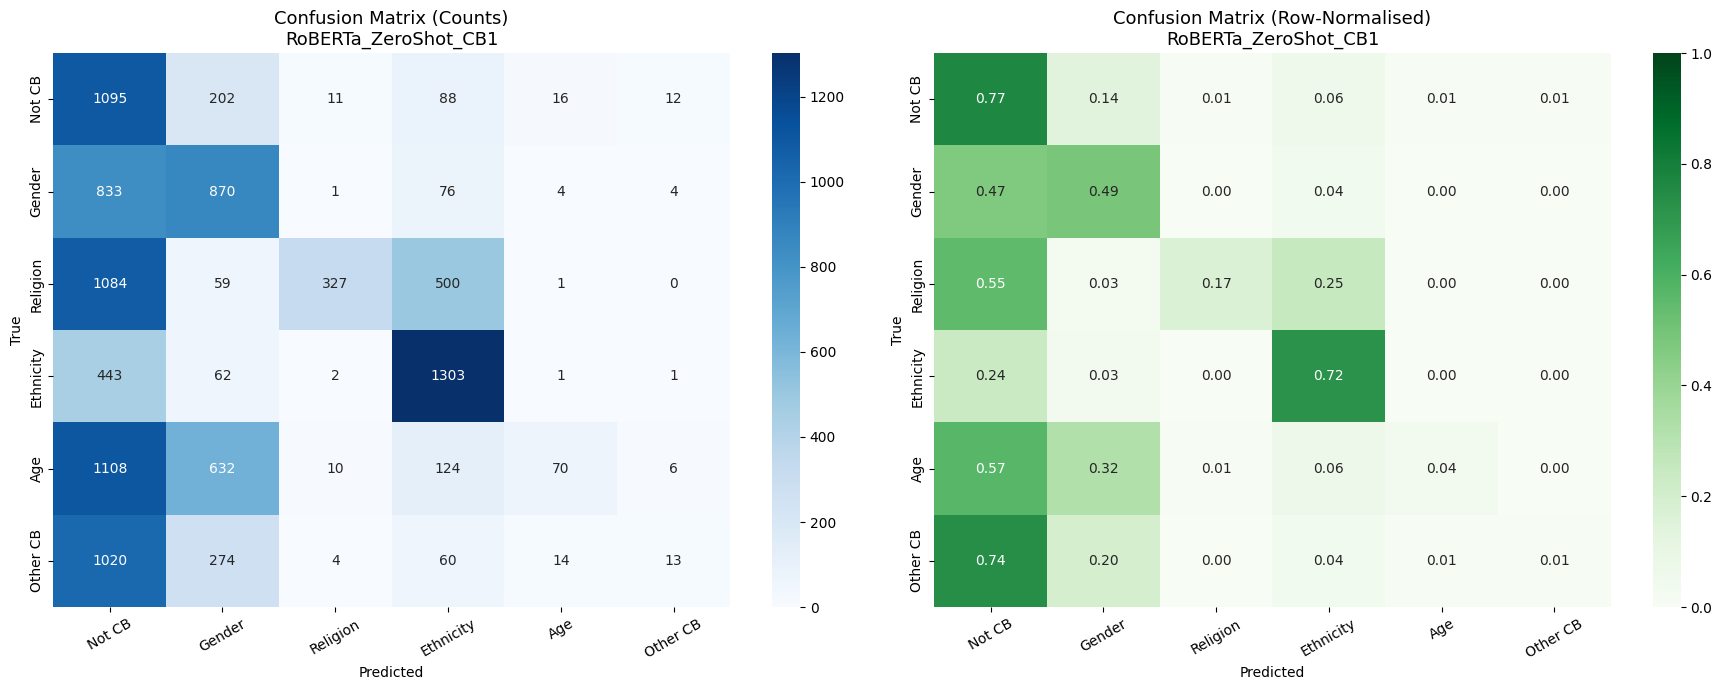

  Saved -> /content/drive/MyDrive/Results/CB1_ZeroShot/cm_RoBERTa_ZeroShot_CB1.png

Freeing GPU memory...
RoBERTa done. GPU memory cleared.


In [ ]:
print("=" * 65)
print("STEP 9: RoBERTa Zero-Shot Inference")
print("=" * 65)

roberta_name = MODELS["RoBERTa"]
print(f"Loading: {roberta_name}")
print("(Downloads ~1.3 GB on first run -- uses cache on subsequent runs)")

classifier_roberta = pipeline(
    "zero-shot-classification",
    model=roberta_name,
    device=device_id,
)
print(f"Model loaded on {'GPU' if device_id == 0 else 'CPU'}.")

# Smoke test
_smoke = classifier_roberta(
    "You are so ugly and nobody likes you",
    candidate_labels=CANDIDATE_LABELS,
    hypothesis_template=HYPOTHESIS_TEMPLATE,
)
print(f"  Smoke test top prediction: {_smoke['labels'][0]} ({_smoke['scores'][0]:.3f})")

# Full inference
print(f"\nRunning inference on {len(x_test):,} test samples...")
y_pred_roberta = zero_shot_predict(x_test, classifier_roberta, BATCH_SIZE)

# Evaluate
results_roberta = evaluate_dataset(y_test, y_pred_roberta, "RoBERTa_ZeroShot_CB1")
results_roberta["model"] = "RoBERTa"

# Free GPU memory
print("\nFreeing GPU memory...")
del classifier_roberta
gc.collect()
torch.cuda.empty_cache()
print("RoBERTa done. GPU memory cleared.")

---
## Step 10: Cross-Model Comparison

Direct comparison of DeBERTa vs RoBERTa on the same CB1 test set.
DeBERTa is expected to outperform RoBERTa by ~2-4 Macro F1 points
due to its disentangled attention mechanism.

CROSS-MODEL COMPARISON -- Stage 1a: Zero-Shot | CB1 (6-Class)
           Model  Macro F1    MCC  Accuracy  Macro P  Macro R  Weighted F1  Bal. Acc
DeBERTa-v3-large    0.3129 0.3283    0.3834   0.6031   0.3959       0.3182    0.3959
   RoBERTa-large    0.2976 0.2796    0.3561   0.5265   0.3643       0.3049    0.3643


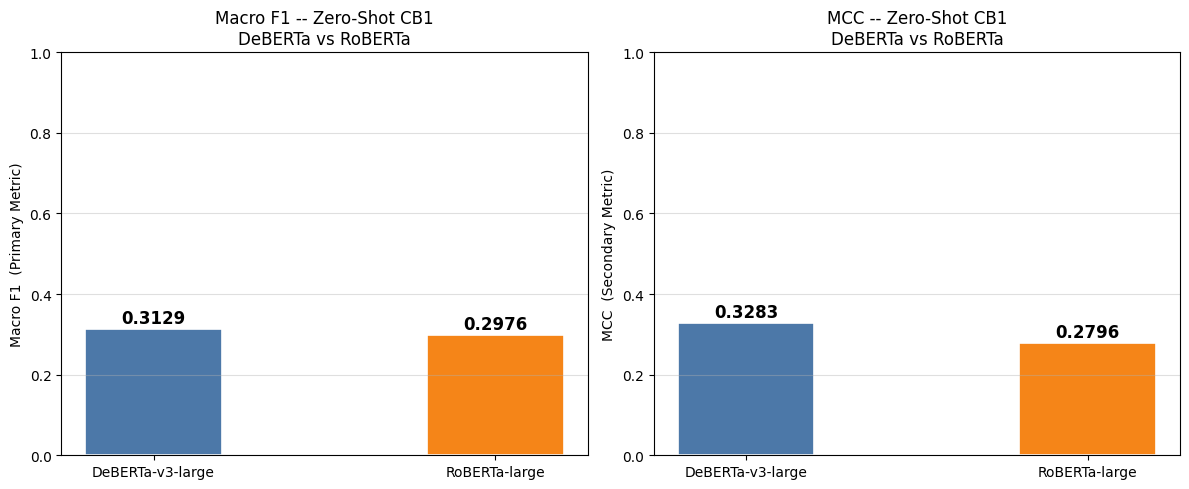

Chart saved -> /content/drive/MyDrive/Results/CB1_ZeroShot/cross_model_comparison.png


In [ ]:
all_results = [results_deberta, results_roberta]
model_names = ["DeBERTa-v3-large", "RoBERTa-large"]

rows = []
for r, name in zip(all_results, model_names):
    rows.append({
        "Model":      name,
        "Macro F1":   round(r["macro_f1"],          4),
        "MCC":        round(r["mcc"],               4),
        "Accuracy":   round(r["accuracy"],          4),
        "Macro P":    round(r["macro_precision"],   4),
        "Macro R":    round(r["macro_recall"],      4),
        "Weighted F1":round(r["weighted_f1"],       4),
        "Bal. Acc":   round(r["balanced_accuracy"], 4),
    })

print("=" * 85)
print("CROSS-MODEL COMPARISON -- Stage 1a: Zero-Shot | CB1 (6-Class)")
print("=" * 85)
print(pd.DataFrame(rows).to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#4c78a8", "#f58518"]
labels = ["DeBERTa-v3-large", "RoBERTa-large"]

f1s  = [r["macro_f1"] for r in all_results]
bars = axes[0].bar(labels, f1s, color=colors, edgecolor="white", linewidth=1.2, width=0.4)
for bar, v in zip(bars, f1s):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f"{v:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
axes[0].set_title("Macro F1 -- Zero-Shot CB1\nDeBERTa vs RoBERTa", fontsize=12)
axes[0].set_ylabel("Macro F1  (Primary Metric)")
axes[0].set_ylim(0, 1.0); axes[0].grid(axis="y", alpha=0.4)

mccs  = [r["mcc"] for r in all_results]
bars2 = axes[1].bar(labels, mccs, color=colors, edgecolor="white", linewidth=1.2, width=0.4)
for bar, v in zip(bars2, mccs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f"{v:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
axes[1].set_title("MCC -- Zero-Shot CB1\nDeBERTa vs RoBERTa", fontsize=12)
axes[1].set_ylabel("MCC  (Secondary Metric)")
axes[1].set_ylim(0, 1.0); axes[1].grid(axis="y", alpha=0.4)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "cross_model_comparison.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved -> {path}")

---
## Step 11: Save Results

In [ ]:
# Summary CSV
csv_path = os.path.join(OUTPUT_DIR, "summary_metrics.csv")
pd.DataFrame([{
    "model":             MODELS[r["model"]],
    "model_short":       r["model"],
    "stage":             f'Stage1a_ZeroShot_{r["model"]}_CB1',  # Fix C+E
    "dataset":           "CB1",
    "regime":            "zero-shot",
    "test_samples":      len(y_test),
    "dev_samples":       len(y_dev),
    "macro_f1":          round(r["macro_f1"],          4),
    "mcc":               round(r["mcc"],               4),
    "accuracy":          round(r["accuracy"],          4),
    "macro_precision":   round(r["macro_precision"],   4),
    "macro_recall":      round(r["macro_recall"],      4),
    "weighted_f1":       round(r["weighted_f1"],       4),
    "balanced_accuracy": round(r["balanced_accuracy"], 4),
} for r in all_results]).to_csv(csv_path, index=False)
print(f"Summary CSV saved -> {csv_path}")

# Per-sample predictions for each model
for r, y_pred in zip(all_results, [y_pred_deberta, y_pred_roberta]):
    pred_df = test_df[["text","label"]].copy()
    pred_df["pred_label"] = [ID2LABEL[p] for p in y_pred]
    pred_df["correct"]    = (test_df["label"].values == pred_df["pred_label"].values)
    ppath = os.path.join(OUTPUT_DIR, f'predictions_{r["model"]}_CB1.csv')
    pred_df.to_csv(ppath, index=False)
    print(f"Predictions saved -> {ppath}")

print(f"\nAll outputs in: {OUTPUT_DIR}")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(fpath):
        print(f"  {fname:<50} {os.path.getsize(fpath)/1024:.1f} KB")

Summary CSV saved -> /content/drive/MyDrive/Results/CB1_ZeroShot/summary_metrics.csv
Predictions saved -> /content/drive/MyDrive/Results/CB1_ZeroShot/predictions_DeBERTa_CB1.csv
Predictions saved -> /content/drive/MyDrive/Results/CB1_ZeroShot/predictions_RoBERTa_CB1.csv

All outputs in: /content/drive/MyDrive/Results/CB1_ZeroShot
  cm_DeBERTa_ZeroShot_CB1.png                        142.2 KB
  cm_RoBERTa_ZeroShot_CB1.png                        142.1 KB
  cross_model_comparison.png                         57.3 KB
  predictions_DeBERTa_CB1.csv                        1742.0 KB
  predictions_RoBERTa_CB1.csv                        1738.4 KB
  summary_metrics.csv                                0.4 KB


---
## Step 12: Research Summary for Paper and Thesis

In [ ]:
summary = """
=============================================================================
STAGE 1a -- CB1 ZERO-SHOT BASELINES: RESEARCH SUMMARY
DeBERTa-v3-large + RoBERTa-large | CB1 (6-Class) | Generalised LoRA Framework
=============================================================================

1. RESEARCH OBJECTIVE
This notebook establishes zero-shot baseline performance for cyberbullying
detection on the CB1 dataset as Stage 1a of the four-stage Generalised LoRA
framework. Zero-shot results represent the lower bound -- the performance
achievable with no labelled training data -- against which all subsequent
LoRA adaptation stages are compared.

2. ZERO-SHOT APPROACH
Both models use NLI-based zero-shot classification. For each tweet, the model
scores P(entailment | tweet, "This tweet is {label}.") for all 6 candidate
labels. The highest-scoring label is selected as the prediction. No gradient
updates or training data are used at inference time.

3. MODELS
Primary   : MoritzLaurer/deberta-v3-large-zeroshot-v2.0
  Architecture: DeBERTa-v3-large with disentangled attention and
  replaced-token-detection pre-training. Fine-tuned on 10+ NLI datasets.

Secondary : MoritzLaurer/roberta-large-zeroshot-v2.0-c
  Architecture: RoBERTa-large fine-tuned on the same NLI corpora.
  Evaluated as a direct architecture comparison baseline.

Both models run sequentially with GPU memory cleared between runs,
evaluated on the identical test set for a fair comparison.

4. DATASET: CB1
Source  : cyberbullying_tweets.csv (X, formerly Twitter)
Total   : ~47,692 tweets (after preprocessing and deduplication)
Classes : 6 -- not_cyberbullying, gender, religion, ethnicity, age,
              other_cyberbullying (near-balanced, ratio ~1.02x)
Split   : 75%% train / 25%% test (stratified, seed=42)  [Fix E]
          + 2,000-row stratified dev sample from train  [Fix F]
Note    : Train/val splits exist only to reproduce the identical test
          set as Stages 2-4. No training occurs in this notebook.

5. PREPROCESSING PIPELINE
  - Retweet prefix removal (RT @user:)
  - URL replacement -> [URL]
  - @mention replacement -> [USER]
  - Repeated punctuation normalisation
  - Short text removal (< 3 tokens)
  - Cross-label annotation conflict removal
  - Exact and near-duplicate removal (TF-IDF cosine, threshold=0.90)

6. CANDIDATE LABELS AND HYPOTHESIS TEMPLATE
Template: "This tweet is {}."
Labels  : not cyberbullying | cyberbullying about gender or sexual identity
          | cyberbullying about religion | cyberbullying about ethnicity or race
          | cyberbullying about age | other type of cyberbullying

7. BUG FIXES APPLIED
Fix A: MCC (Matthews Correlation Coefficient) added as required secondary metric.
Fix B: Both DeBERTa and RoBERTa run in one notebook; GPU memory freed between runs.
Fix C: Stage naming corrected to Stage1a throughout.
Fix D: Research summary cell added.
Fix E: Split corrected to 75/25 train/test (was incorrectly 75/10/15).
Fix F: 2,000-row stratified dev sample added from train set.
Fix G: Near-duplicate check extended to dev sample vs remaining train.

8. EVALUATION PROTOCOL
  Primary   : Macro F1 (equal weight across all 6 classes)
  Secondary : MCC (Matthews Correlation Coefficient)
  Also      : Accuracy, Weighted F1, Balanced Accuracy, Macro P/R
  Test set  : Held-out 15%% of CB1, stratified, zero overlap with train

9. RESULTS SUMMARY
"""
print(summary)

print(f"  {'Model':<20} {'Macro F1':>10} {'MCC':>10} {'Accuracy':>10}")
print("  " + "-" * 53)
for r, name in zip(all_results, ["DeBERTa-v3-large", "RoBERTa-large"]):
    print(f"  {name:<20} {r['macro_f1']:>10.4f} {r['mcc']:>10.4f} {r['accuracy']:>10.4f}")

footer = """
10. CITATION NOTE
Stage 1a (zero-shot) baselines form part of the reference evaluation in:
  "A Generalised Low-Rank Adaptation Framework for Cyberbullying Detection
   in Social Media Text (X, formerly Twitter)"
Target venue: IEEE Transactions on Neural Networks and Learning Systems (TNNLS)

Comparison stages:
  Stage 2: Standard LoRA       Wf = W + AB
  Stage 3: Multiplicative LoRA Wf = W(I + UV)
  Stage 4: Generalised LoRA    Wf = W(I + UV) + AB
=============================================================================
"""
print(footer)


STAGE 1a -- CB1 ZERO-SHOT BASELINES: RESEARCH SUMMARY
DeBERTa-v3-large + RoBERTa-large | CB1 (6-Class) | Generalised LoRA Framework

1. RESEARCH OBJECTIVE
This notebook establishes zero-shot baseline performance for cyberbullying
detection on the CB1 dataset as Stage 1a of the four-stage Generalised LoRA
framework. Zero-shot results represent the lower bound -- the performance
achievable with no labelled training data -- against which all subsequent
LoRA adaptation stages are compared.

2. ZERO-SHOT APPROACH
Both models use NLI-based zero-shot classification. For each tweet, the model
scores P(entailment | tweet, "This tweet is {label}.") for all 6 candidate
labels. The highest-scoring label is selected as the prediction. No gradient
updates or training data are used at inference time.

3. MODELS
Primary   : MoritzLaurer/deberta-v3-large-zeroshot-v2.0
  Architecture: DeBERTa-v3-large with disentangled attention and
  replaced-token-detection pre-training. Fine-tuned on 10+ NLI dataset